## Librerías.

In [1]:
import sys
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial'
if project_path not in sys.path:
    sys.path.append(project_path)

Mounted at /content/drive


In [3]:
# Configuramos direcciones.
data_dir = os.path.join(project_path, 'data/binary')
path_base = os.path.join(project_path, 'models/celeba_base.h5')

In [4]:
# Creamos los generadores.
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)

# Generador de entrenamiento.
train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='training',
    shuffle=True)

# Generador de validación.
valid_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    shuffle=False)

Found 120 images belonging to 2 classes.
Found 29 images belonging to 2 classes.


In [5]:
# Cargamos el modelo preentrenado.
base_model = tf.keras.models.load_model(path_base)

# Creamos el extractor de características.
feature_extractor = tf.keras.Sequential(base_model.layers[:8])

feature_extractor.trainable = False

# Añadimos el mejor clasificador.
inputs = layers.Input(shape=(224, 224, 3))
x = feature_extractor(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0015))(x)
x = layers.Dropout(.6)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=inputs, outputs=output)

In [6]:
# Compilamos.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [7]:
# Vemos la arquitectura del modelo.
print("Arquitectura del Modelo:")
model.summary()

Arquitectura del Modelo:


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 12, 12, 128)    │       240,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,153 (973.25 KB)

 Trainable params: 8,321 (32.50 KB)

 Non-trainable params: 240,832 (940.75 KB)

In [8]:
# Entrenamos.
ruta_mejor_modelo = os.path.join(project_path, 'models/mi_reconocedor_p1.h5')

early_stopping = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    filepath=ruta_mejor_modelo,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

history_final = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50,
    callbacks=[early_stopping, checkpoint],
    verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5156 - loss: 0.8193

15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5209 - loss: 0.8192 - val_accuracy: 0.6207 - val_loss: 0.8175
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5198 - loss: 0.8162

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step - accuracy: 0.5243 - loss: 0.8161 - val_accuracy: 0.6552 - val_loss: 0.8150
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.6006 - loss: 0.8134 - val_accuracy: 0.5862 - val_loss: 0.8124
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 244ms/step - accuracy: 0.7078 - loss: 0.8085 - val_accuracy: 0.6552 - val_loss: 0.8102
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.7921 - loss: 0.8035 - val_accuracy: 0.6207 - val_loss: 0.8069
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7611 - loss: 0.8026

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 335ms/step - accuracy: 0.7604 - loss: 0.8025 - val_accuracy: 0.6897 - val_loss: 0.8053
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.6483 - loss: 0.8015 - val_accuracy: 0.6897 - val_loss: 0.8021
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.8451 - loss: 0.7942 - val_accuracy: 0.6897 - val_loss: 0.7995
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 284ms/step - accuracy: 0.8364 - loss: 0.7920 - val_accuracy: 0.6897 - val_loss: 0.7976
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7115 - loss: 0.7925

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - accuracy: 0.7144 - loss: 0.7923 - val_accuracy: 0.7241 - val_loss: 0.7950
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 244ms/step - accuracy: 0.6930 - loss: 0.7887 - val_accuracy: 0.6207 - val_loss: 0.7933
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 244ms/step - accuracy: 0.7512 - loss: 0.7856 - val_accuracy: 0.6552 - val_loss: 0.7911
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.7603 - loss: 0.7838

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.7607 - loss: 0.7837 - val_accuracy: 0.7586 - val_loss: 0.7886
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.7784 - loss: 0.7803 - val_accuracy: 0.7586 - val_loss: 0.7860
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.7699 - loss: 0.7772 - val_accuracy: 0.7586 - val_loss: 0.7842
Epoch 16/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7838 - loss: 0.7745

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 342ms/step - accuracy: 0.7812 - loss: 0.7746 - val_accuracy: 0.7931 - val_loss: 0.7818
Epoch 17/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.7824 - loss: 0.7695 - val_accuracy: 0.7586 - val_loss: 0.7794
Epoch 18/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.8168 - loss: 0.7675 - val_accuracy: 0.7931 - val_loss: 0.7768
Epoch 19/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 326ms/step - accuracy: 0.8100 - loss: 0.7663 - val_accuracy: 0.7241 - val_loss: 0.7752
Epoch 20/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.7865 - loss: 0.7625 - val_accuracy: 0.6552 - val_loss: 0.7741
Epoch 21/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.7449 - loss: 0.7590 - val_accuracy: 0.7241 - val_loss: 0.7717
Epoch 22/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 298ms/step - accuracy: 0.7476 - loss: 0.7580 - val_accuracy: 0.7241 - val_loss: 0.7691
Epoch 23/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - accuracy: 0.6935 - loss: 0.7591 - val_accuracy: 0.7241

Gráficas guardadas en: /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/training_metrics.png


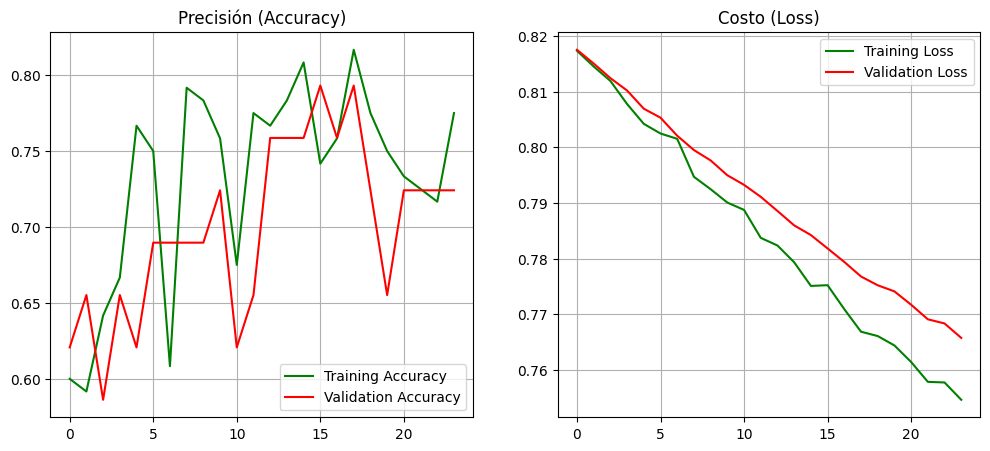

In [9]:
# Gráficas de costo y presición.
acc = history_final.history['accuracy']
val_acc = history_final.history['val_accuracy']
loss = history_final.history['loss']
val_loss = history_final.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de Accuracy.
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, color='green', label='Training Accuracy')
plt.plot(epochs_range, val_acc, color='r', label='Validation Accuracy')
plt.title('Precisión (Accuracy)')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica de Loss (Costo).
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, color='green', label='Training Loss')
plt.plot(epochs_range, val_loss, color='r', label='Validation Loss')
plt.title('Costo (Loss)')
plt.legend(loc='upper right')
plt.grid(True)

imagen_metrics = os.path.join(project_path, 'training_metrics.png')
plt.savefig(imagen_metrics)
print(f"Gráficas guardadas en: {imagen_metrics}")

plt.show()